# Descriptive Analysis

This notebook presents a descriptive analysis of the education dataset

In [40]:
#required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# The variables

The data were collected from two schools in the Alentejo region of Portugal during the 2005-2006 school year from students of Mathematics and Portuguese. The data were collected from a combination of student reports and questionnaires.
Each instance in the dataset represents a single student, and contains demographics and performance throughout the year in Maths and Portuguese.

In [41]:
# Load the dataset into a data frame
df = pd.read_csv("dataset.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel.p,freetime.p,goout.p,Dalc.p,Walc.p,health.p,absences.p,pG1,pG2,pG3
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,3,1,2,1,1,1,4,13,13,13
1,GP,F,15,R,GT3,T,1,1,other,other,...,3,3,4,2,4,5,2,13,11,11
2,GP,F,15,R,GT3,T,2,2,at_home,other,...,4,3,1,1,1,2,8,14,13,12
3,GP,F,15,R,GT3,T,2,4,services,health,...,4,3,2,1,1,5,2,10,11,10
4,GP,F,15,R,GT3,T,3,3,services,services,...,4,2,1,2,3,3,2,13,13,13


In [42]:
# Display variables and their python data types
df.dtypes

school          object
sex             object
age              int64
address         object
famsize         object
Pstatus         object
Medu             int64
Fedu             int64
Mjob            object
Fjob            object
reason          object
nursery         object
internet        object
guardian.m      object
traveltime.m     int64
studytime.m      int64
failures.m       int64
schoolsup.m     object
famsup.m        object
paid.m          object
activities.m    object
higher.m        object
romantic.m      object
famrel.m         int64
freetime.m       int64
goout.m          int64
Dalc.m           int64
Walc.m           int64
health.m         int64
absences.m       int64
mG1              int64
mG2              int64
mG3              int64
guardian.p      object
traveltime.p     int64
studytime.p      int64
failures.p       int64
schoolsup.p     object
famsup.p        object
paid.p          object
activities.p    object
higher.p        object
romantic.p      object
famrel.p   

The dataset contains 53 variables, which are described in the table below. The variables are also described in Cortez, P., & Silva, A. M. G. (2008). Variables 1 to 15 describe the student's demographic in general. Variables 14 to 33 concern the mathematics class. Variables 34 to 53 concern the Portuguese class. The variables for both subjects have the same format, the only difference is the subject described.

In some cases dichotomous data is encoded in python as a string rather than a binary value. This is somewhat arbitrary and may need to be re-encoded depending on how we plan to used this data. 
All numeric data is discrete and only whole numbers are used in the dataset, therefore only integer numeric values are used to encode the data. Categorical ordinal variables are encoded as numeric values to preserve their ordered nature.

A number of variables are duplicated with identical Maths and Portuguese values, with a very small number of exceptions. These variables should not differ depending on the subject as they relate to the student, but not the subject itself. For example **traveltime.m** and **traveltime.p** which both represent the same travel time to the school.

\* The data of the failures.p and failures.m did not match the description of the variable given by Cortez, P., & Silva, A.M.G (2008). They described it as *n if 1 ≤ n < 3, else 4*, However the data contains mainly zeros, in addition to a small number of ones, twos and threes, but no fours. For this reason I consider them as discrete numeric rather than categorical ordinal.

||Variable Name|Name in dataset|Values|Type|Python type|
|--|--|--|--|--|--|
||**Student's demographics Variables 1-15**|||||
|1.|Student's school|school|Gabriel Perreira (GP) or Mousinho da Silveira(MS)|Dichotomous|string object|
|2.|Student's sex |sex|M or F|Dichotomous|string object|
|3.|Student's age|age|15 - 22|Discrete numeric, ratio scale|int64|
|4.|Students home address|address|Rural (R) or Urban (U)|dichotomous| string object|
|5.|Student's family size|famsize|3<=famsize>3|dichotomous|string object|
|6.|Parent's cohabitation status|Pstatus|Living together (T) or apart (A)|dichotomous|string object|
|7.|Mother's education level|Medu|None (0) - Higher Education (4)|categorical ordinal|int64|
|8.|Father's Education|Fedu|None (0) - Higher Education (4)|categorical ordinal|int64|
|9.|Mother's job|Mjob|teacher, health care related, civil services, at home or other|categorical nominal| string object|
|10.|Father's job|Fjob|teacher, health care related, civil services, at home or other|Categorical nominal|string object|
|11.|Reason for student attending this school|reason|close to *home*, school *reputation*, *course* preference, *other*|categorical nominal|string object|
|12.|Student attended nursery school|nursery|yes or no|dichotomous|string object|
|13.|Internet access at home|internet|yes or no|dichotomous|string object|
||**Maths subject variables 14-33**|||||
|14.|Maths - Student's guardian|guardian.m|Mother, Father, Other|categorical nominal|string object|
|15.|Maths - Travel time from home to school|traveltime.m  |1 (1-15mins), 2 (15-30mins), 3 (30mins-1hour), 4 (>1hour)|categorical ordinal|   int64|
|16.|Maths - study time per week|studytime.m   |1 (<2hours), 2 (2-5hours), 3 (5-10 hours), 4 (>10hours)|categorical ordinal|int64|
|17.|Maths - No. of past class failures|failures.m|1<=n<3, else 4|numeric, ratio scale\*|   int64|
|18.|Maths - Extra educational school support|schoolsup.m|yes or no|dichotomous|string object|
|19.|Maths - Familial education support|famsup.m|yes or no|dichotomous|string object|
|20.|Maths - extra paid classes|paid.m |yes or no|dichotomous|string object|
|21.|Maths - Extra curricular activities|activities.m  |yes or no|dichotomous|string object|
|22.|Maths - Student wants to continue to higher education|higher.m|yes or no|dichotomous|string object|
|23.|Maths - Student has a romantic relationship|romantic.m |yes or no|dichotomous|string object|
|24.|Maths - Quality of family relationships|famrel.m|1 (very bad) - 5 (excellent)|categorical ordinal|   int64|
|25.|Maths - Free time after school|freetime.m|1 (very low) - 5 (very high)|categorical ordinal|   int64|
|26.|Maths - How often student goes out with friends|goout.m |1 (very low) - 5 (very high)|categorical ordinal|   int64|
|27.|Maths - Alcohol consumption on weekdays|Dalc.m|1 (very low) - 5 (very high)|categorical ordinal|   int64|
|28.|Maths - Alcohol consumption on weekends|Walc.m        |1 (very low) - 5 (very high)|categorical ordinal| int64|
|29.|Maths - Current health statis|health.m      |1 (very bad) - 5 (very good)|categorical ordinal|   int64|
|30.|Maths - Number of absences|absences.m    |0-93|numeric, ratio scale|   int64|
|31.|Maths - Grade for period 1|mG1           |0-20|numeric, ordinal |   int64|
|32.|Maths - Grade for period 2|mG2           |0-20|numeric, ordinal|   int64|
|33.|Maths - Final Grade|mG3 |0-20|numeric, ordinal|   int64|
||**Portuguese subject variables** 34-53|||||
|34.|Portuguese - Student's guardian|guardian.p|Mother, Father, Other|categorical nominal|string object|
|35.|Portuguese - Travel time from home to school|traveltime.p  |1 (1-15mins), 2 (15-30mins), 3 (30mins-1hour), 4 (>1hour)|categorical ordinal|   int64|
|36.|Portuguese - study time per week|studytime.p   |1 (<2hours), 2 (2-5hours), 3 (5-10 hours), 4 (>10hours)|categorical ordinal|int64|
|37.|Portuguese - No. of past class failures|failures.p|1<=n<3, else 4|numeric, ratio scale\*|   int64|
|38.|Portuguese - Extra educational school support|schoolsup.p|yes or no|dichotomous|string object|
|39.|Portuguese - Familial education support|famsup.p|yes or no|dichotomous|string object|
|40.|Portuguese - extra paid classes|paid.p |yes or no|dichotomous|string object|
|41.|Portuguese - Extra curricular activities|activities.p |yes or no|dichotomous|string object|
|42.|Portuguese - Student wants to continue to higher education|higher.p|yes or no|dichotomous|string object|
|43.|Portuguese - Student has a romantic relationship|romantic.p |yes or no|dichotomous|string object|
|44.|Portuguese - Quality of family relationships|famrel.p|1 (very bad) - 5 (excellent)|categorical ordinal|   int64|
|45.|Portuguese - Free time after school|freetime.p|1 (very low) - 5 (very high)|categorical ordinal|   int64|
|46.|Portuguese - How often student goes out with friends|goout.p |1 (very low) - 5 (very high)|categorical ordinal|   int64|
|47.|Portuguese - Alcohol consumption on weekdays|Dalc.p|1 (very low) - 5 (very high)|categorical ordinal|   int64|
|48.|Portuguese - Alcohol consumption on weekends|Walc.p        |1 (very low) - 5 (very high)|categorical ordinal| int64|
|49.|Portuguese - Current health statis|health.p      |1 (very bad) - 5 (very good)|categorical ordinal|   int64|
|50.|Portuguese - Number of absences|absences.p  |0-93|numeric, ratio scale|   int64|
|51.|Portuguese - Grade for period 1|pG1           |0-20|numeric, ordinal |   int64|
|52.|Portuguese - Grade for period 2|pG2           |0-20|numeric, ordinal|   int64|
|53.|Portuguese - Final Grade|pG3           |0-20|numeric, ordinal|   int64|

# Visualisation of distributions

To visualise categorical variables they can be plotted on a barchart. 
Numeric variables, including categorical ordinal variables, can be plotted on a histogram.

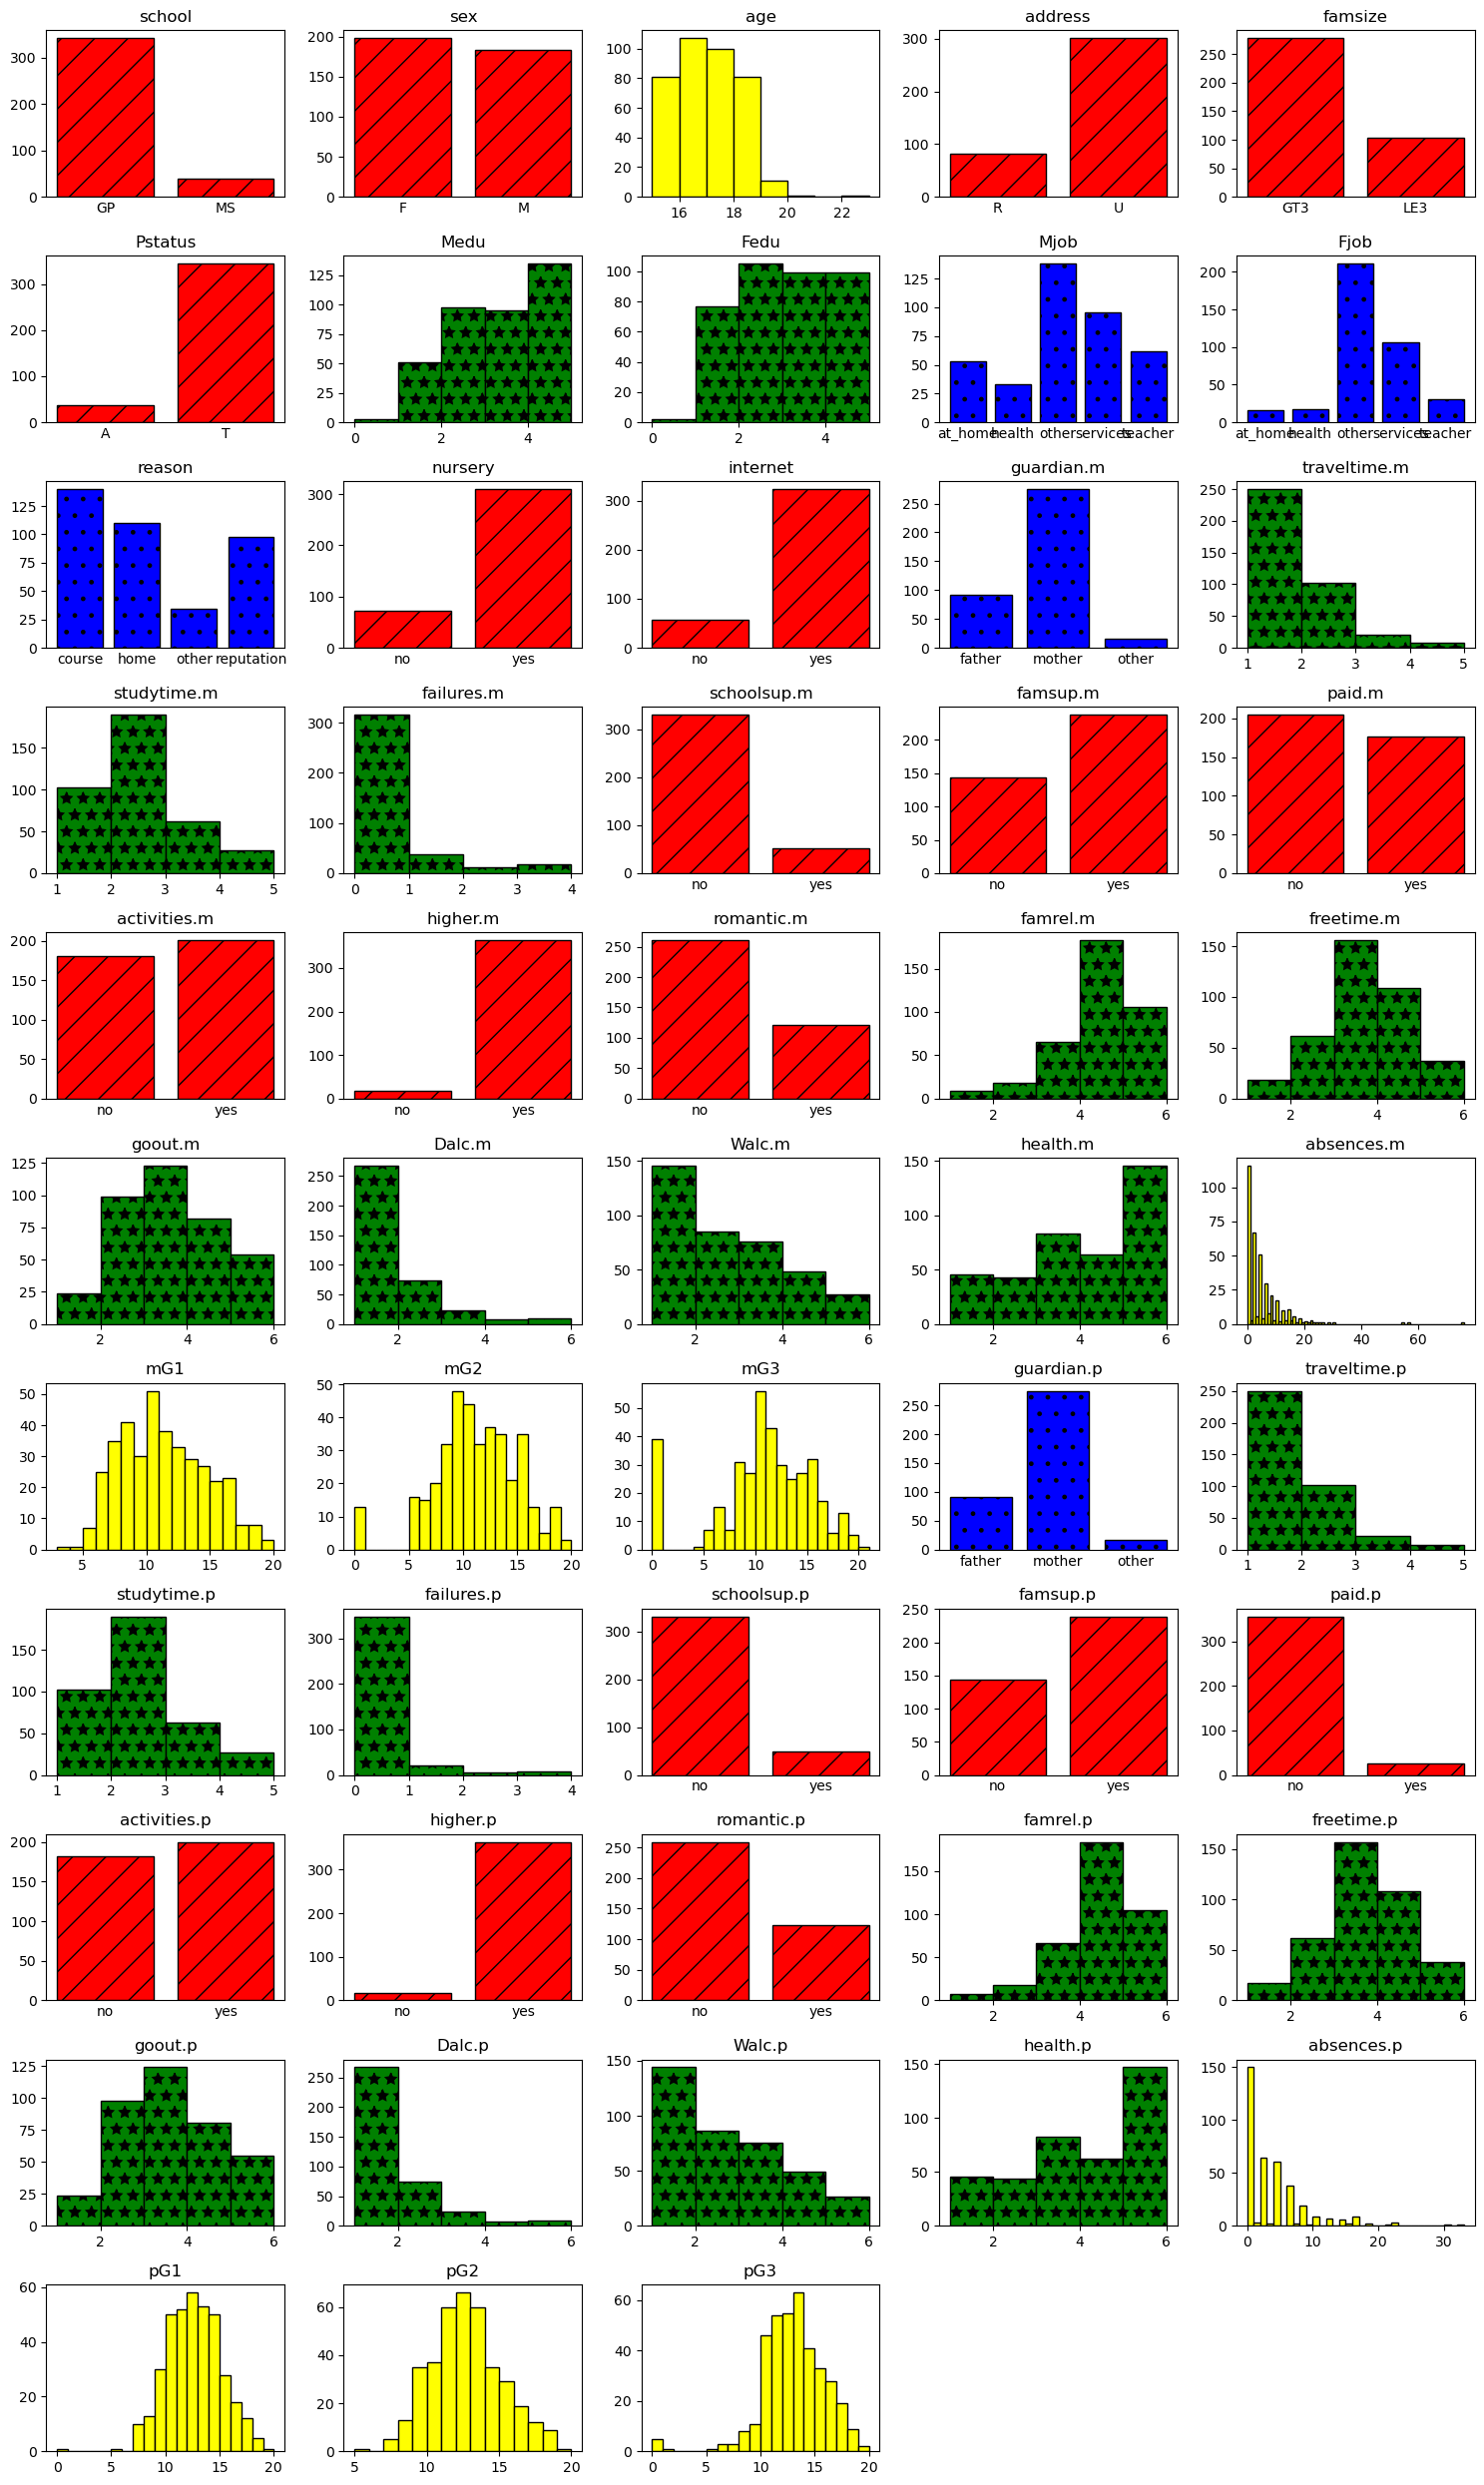

In [43]:
#Plot all variables
# set the figure size for better readability and allow needed space between subplots with tight_layout
plt.figure(figsize=(15,25), tight_layout = True)

# number of rows and columns
nrows = 11; ncols = 5

# iterate over column indices
for i in range(len(df.columns)):
    # check the type, then create 
    # a histogram for numerics
    # a barchart for categoricals
    patterns = [ "/" , "\\" , "|" , "-" , "+" , "x", "o", "O", ".", "*" ]

    plt.subplot(nrows, ncols, i + 1)
    plt.title(df.columns[i])
    if df.dtypes[i] == object :
        
        bar_data = np.unique(df[df.columns[i]], return_counts=True)
        if len(bar_data[0])==2:
            colour = "red"
            hatch = patterns[0]
        else:
            colour = "blue"
            hatch= patterns[8]
        plt.bar(x=range(len(bar_data[0])), height=bar_data[1], color = colour, hatch=hatch, tick_label=bar_data[0],edgecolor='black')
        plt.tick_params(axis='x', length=0)
    else:
        #plot bin adjusted histograms in green - with fixed label positions/intervals
        min_val = df[df.columns[i]].min()
        max_val = df[df.columns[i]].max()
        if(max_val <= 5 ):
            colour="green"
            hatch = patterns[9]
        else: 
            colour="yellow"
            hatch= None
        plt.hist(df[df.columns[i]], color = colour, hatch=hatch, edgecolor='black', bins=range(min_val, max_val+2))
        
plt.show()

The dataset contains many dichotomous variables with only two possible values (plotted above in red (diagonal hatching)). 
Many of these are unbalanced with a large number of students falling into one category rather than into the other. The unbalanced dichotomous variables include: **school**, **address**, **famsize**, **Pstatus**, **nursery**, **internet**, **schoolsup.m**, **fam_sup.m**, **paid.m**, **higher.m**, **romantic.m**, **schoolsup.p**, **paid.p**, **higher.p**, **romantic.p**, **famsup.p**. For example, the distribution of pupils across the two possible **schools** is very unbalanced. There are much fewer students attending Mousinho da Silveira (MS) than Gabriel Perreira (GP). 

The following dichotomous variables have a balanced distribution: **sex**, **activities.m**, **activities.p**. For example, the **sex** of the students is quite balanced, with only a few more female students than male in the dataset.


There are a number of categorical nominal variables that are not dichotomous. These are plotted on in blue (dot hatching) on the bar charts above and display a variety of different frequencies but none have uniform distributions. The **guardian.p** and **guardian.m** variables show that *mother* is by far the most common student's guardian. This is interesting because the parental status **Pstatus** variable indicates that students' parents are overwhelmingly noted as *together*.

Categorical ordinal variables are plotted on in green (star hatching) in the histograms above displaying their distributions. The histogram bins are set to 1 unit to make reading the histograms easier. Some of the variables, such as **freetime.m**, **freetime.p**, **goout.p** and **goout.m** have a normal distribution. Others such as **traveltime.m**, **Walc.m**, **Walc.p** show a constantly decreasing distribution.

Numeric variables are plotted on yellow (no hatching) histograms.
Grade related variables such as **mG1**, **mG2**, **mG3m**, **pG1**, **pG2**, **pG3** all show a roughly normal distribution, other than outliers where a grade of 0 was recieved by students.
Absences have an unusual pattern with an exponentially decreasing distribution especially in the case of **absences.m** more than **absences.p**. Data may be missing for every second day in both **absence** variables, as indicated by the gaps on the histogram.

The age of students fell mostly between 16 and 19, with a couple of outliers over 20 years old. 


# Data processing based on domain knowledge

### Dichotomous variables represented by strings in the dataset
Converting dichotomous variable, mostly of the format "yes" and "no" to binary variables is possible and may be useful depending on the applications required. However, it is not inherently necessary to do to process the data effectively as it doesn't matter for analysis purposes. 


## Invalid Entries

### Duplicated data
There are a number of rows where data that should reasonably match does not. From Cortes, P. & Silva, A. M. G (2008) it appears that two datasets were originally created, one containing Maths students' data and the other Portuguese. Some variables should reasonably be the same for both classes such as a student's **health**, or **weekend alcohol consumption**. These variables should not vary between subjects as they should both refer to the same student during the same time period (2005-2006 school year). It seems likely that there was some inconsistency at the time of data collection, or when merging the two datasets. Since there are only 12 instances of rows with conflicting data, we will remove these students from our analysis.

Once the conflicting data is removed we can merge any columns where the data matches for the Maths and Portuguese versions of the student's family relationship quality, main guardian, travel time to school, extracurricular activities, desire to continue to higher education, romantic relationships, quantity of free time after school, frequency of going out socialising, weekday alcohol frequency, weekend alcohol frequency, and health ("famrel","guardian", "traveltime","activities","higher", "romantic", "freetime", "goout", "Dalc", "Walc","health").


### Outliers
There are some outliers visible in the grades for both Mathematics and Portuguese, particularly the final grades, where students have received a 0 grade. This seems unlikely to be a true grade result due to the student failing the exams or failing to complete coursework. However as even the 0 grade may depend on other factors such as the student's family support, or attendence levels this is still of interest and these outliers can still be informative when investigating the features that contribute to a student's grade. For this reason the outliers will not be removed for the current analysis.

From looking at the plots of the grade distributions it appears that there are far fewer 0 grades for portuguese than maths. Additionally it seems that students were less likely to receive a 0 grade in the first grade (mG1 or pG1) than in the second or final grade. This may indicate that something other than absences is influencing the grade, or that something (e.g. stress) is causing students not to attend the final grading, particularly in Mathematics.


In [44]:
# Check which .p and .m columns are duplicates / near duplicates
from collections import defaultdict
duplicated_columns_list = []

number_of_students = len(df)

index_to_cols = defaultdict(list)

for col in df.columns:
    m_suffix=".m"
    p_suffix = ".p"

    if col.endswith(m_suffix):
        print(col)
        col_without_suffix = col.removesuffix(m_suffix)
       
        index_list = df[df[col]!=df[col_without_suffix + p_suffix]].index.values.tolist()
        
        #print("Rows:", index_list)
        
        proportion_of_non_matches = len(index_list) / number_of_students
        if proportion_of_non_matches < 0.05:  # < 5% of students
            print(col)
            for ind in index_list:
                index_to_cols[ind].append(col_without_suffix)
       
        
        #print the number of matches and non matches between the maths and portuguese version of variables
        print((df[col]==df[col_without_suffix + p_suffix]).value_counts())
        print()

from pprint import pprint
pprint(index_to_cols)



print( [ind for ind in index_to_cols if "absences" in index_to_cols[ind]])

duplicated_columns = sorted(set([col_name for col_names in index_to_cols.values() for col_name in col_names])) # all columns where <10% of students had mismatched values
data = [ind for ind in index_to_cols if "absences" in index_to_cols[ind]]
newdf = pd.DataFrame( columns = duplicated_columns)

newdf.append(index_to_cols, ignore_index=True, )

#pd.concat(newdf, index_list, )


guardian.m
guardian.m
True     376
False      6
dtype: int64

traveltime.m
traveltime.m
True     377
False      5
dtype: int64

studytime.m
studytime.m
True     373
False      9
dtype: int64

failures.m
True     329
False     53
dtype: int64

schoolsup.m
schoolsup.m
True     379
False      3
dtype: int64

famsup.m
famsup.m
True     377
False      5
dtype: int64

paid.m
True     211
False    171
dtype: int64

activities.m
activities.m
True     377
False      5
dtype: int64

higher.m
higher.m
True     378
False      4
dtype: int64

romantic.m
romantic.m
True     376
False      6
dtype: int64

famrel.m
famrel.m
True     372
False     10
dtype: int64

freetime.m
freetime.m
True     371
False     11
dtype: int64

goout.m
goout.m
True     372
False     10
dtype: int64

Dalc.m
Dalc.m
True     377
False      5
dtype: int64

Walc.m
Walc.m
True     370
False     12
dtype: int64

health.m
health.m
True     374
False      8
dtype: int64

absences.m
False    280
True     102
dtype: int64

defaultdi

C:\Users\garve\AppData\Local\Temp\ipykernel_6848\2718863530.py:43: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  newdf.append(index_to_cols, ignore_index=True, )


,Dalc,Walc,activities,famrel,famsup,freetime,goout,guardian,health,higher,...,253,256,325,328,284,287,356,131,152,250
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,"[guardian, studytime, activities, higher, roma...","[guardian, studytime, activities, higher, roma...","[guardian, traveltime, studytime, famsup, famr...","[guardian, traveltime, studytime, famsup, famr...","[traveltime, schoolsup, activities, higher, fa...","[traveltime, schoolsup, activities, higher, fa...","[traveltime, romantic, famrel, freetime, goout...","[studytime, activities, romantic, freetime, go...","[studytime, schoolsup, famrel, freetime, goout...","[studytime, famsup, goout, Walc]"


In [45]:
# Count rows where the maths value doesn't match the portuguese value

# Collect columns where the maths and portuguese values should reasonably be the same.
differences = ["famrel","guardian", "traveltime","activities","higher", "romantic", "freetime", "goout", "Dalc","Walc", "health", "studytime", "famsup", "schoolsup"] 

indices_list = []
for i in differences:
    #count rows where the portuguese and maths value are different
    num_diff = sum(df[i+".p"]!=df[i+".m"])
    #identify the indices of rows where the values don't match
    indices = df[df[i+".p"]!=df[i+".m"]].index
    for ind in indices:
        if ind not in indices_list:
            indices_list.append(ind)
    print(i,":", num_diff, "\tnon-matches:", indices.values)
    
print()
print("Number of rows where values that probably should match don't:", len(indices_list))
indices_list.sort()
print("Row indices with non-matches:", indices_list)
print()
print("Rows with conflicting data:")
print(df.iloc[indices_list].to_string())


famrel : 10 	non-matches: [152 241 242 253 256 284 287 325 328 356]
guardian : 6 	non-matches: [241 242 253 256 325 328]
traveltime : 5 	non-matches: [284 287 325 328 356]
activities : 5 	non-matches: [131 253 256 284 287]
higher : 4 	non-matches: [253 256 284 287]
romantic : 6 	non-matches: [131 241 242 253 256 356]
freetime : 11 	non-matches: [131 152 241 242 253 256 284 287 325 328 356]
goout : 10 	non-matches: [131 152 250 253 256 284 287 325 328 356]
Dalc : 5 	non-matches: [253 256 325 328 356]
Walc : 12 	non-matches: [131 152 241 242 250 253 256 284 287 325 328 356]
health : 8 	non-matches: [131 152 241 242 284 287 325 328]
studytime : 9 	non-matches: [131 152 241 242 250 253 256 325 328]
famsup : 5 	non-matches: [241 242 250 325 328]
schoolsup : 3 	non-matches: [152 284 287]

Number of rows where values that probably should match don't: 12
Row indices with non-matches: [131, 152, 241, 242, 250, 253, 256, 284, 287, 325, 328, 356]

Rows with conflicting data:
    school sex  age a

In [46]:
#remove invalid rows

df = df.loc[~df.index.isin(indices_list)]

#merge duplicate columns
for col_name in differences:
    #df[col_name] = df[col_name+".p"]
    df= df.rename(columns={col_name+".p": col_name})

    #df = df.drop([col_name+".p", col_name+".m"], axis=1)
    df = df.drop([col_name+".m"], axis=1)

df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,3,1,2,1,1,1,4,13,13,13
1,GP,F,15,R,GT3,T,1,1,other,other,...,3,3,4,2,4,5,2,13,11,11
2,GP,F,15,R,GT3,T,2,2,at_home,other,...,4,3,1,1,1,2,8,14,13,12
3,GP,F,15,R,GT3,T,2,4,services,health,...,4,3,2,1,1,5,2,10,11,10
4,GP,F,15,R,GT3,T,3,3,services,services,...,4,2,1,2,3,3,2,13,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,MS,M,18,U,LE3,T,1,3,at_home,services,...,4,3,3,2,3,3,0,9,10,9
378,MS,M,18,U,LE3,T,4,4,teacher,services,...,4,2,2,2,2,5,0,15,16,16
379,MS,M,19,R,GT3,T,1,1,other,other,...,4,4,4,3,3,5,4,8,9,10
380,MS,M,19,R,GT3,T,1,1,other,services,...,5,4,4,3,3,2,8,10,9,11


# Statistics of central tendency and variation

To describe the central tendency and variation of a numeric variable a number of statistics can be used, such as the count, mean, standard deviation, minimum value, maximum value, quartiles.

In [50]:
description = df[df.columns[(df.dtypes != object)]].describe()

print(description)

              age        Medu        Fedu  failures.m  absences.m         mG1  \
count  370.000000  370.000000  370.000000  370.000000  370.000000  370.000000   
mean    16.575676    2.800000    2.556757    0.278378    5.381081   10.891892   
std      1.180672    1.083505    1.086138    0.710599    7.665653    3.345375   
min     15.000000    0.000000    0.000000    0.000000    0.000000    3.000000   
25%     16.000000    2.000000    2.000000    0.000000    0.000000    8.000000   
50%     17.000000    3.000000    3.000000    0.000000    4.000000   11.000000   
75%     17.000000    4.000000    3.750000    0.000000    8.000000   13.000000   
max     22.000000    4.000000    4.000000    3.000000   75.000000   19.000000   

              mG2         mG3  traveltime   studytime  ...      famrel  \
count  370.000000  370.000000  370.000000  370.000000  ...  370.000000   
mean    10.751351   10.464865    1.445946    2.043243  ...    3.935135   
std      3.800986    4.608830    0.701178    0.8

The mean age of the students is 16.6 years old. 

The average final received in mathematics (of the three grades) was ~10 out of 20, and for portuguese it was ~12/20.

On average students had 5.4 absences from maths class (*STD*=7.7), and 3.6 from portuguese class (*STD*=4.8). The high standard deviation suggest a wide range in the number of absences.

The average weekday alcohol consumption was 1.48 on a scale from 1 to 5, meaning the average student only consumes alcohol moderately during the week. Weekend alcohol frequency was higher at 2.29. 

The mean family relationship score was 3.94 out of 5, suggesting good relationships on average.









In [48]:
#select only categorical / object variables
df[df.columns[(df.dtypes == object)]].mode()

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,nursery,internet,paid.m,guardian,schoolsup,famsup,paid.p,activities,higher,romantic
0,GP,F,U,GT3,T,other,other,course,yes,yes,no,mother,no,yes,no,yes,yes,no


To describe the central tendency of a categorical variable the mode is used.

It was most common for students to attend the school Gabriel Perreira, to be female, to live in an urban area, to have more than 3 people in their family, etc. 

The distributions of these variables are visible in the barcharts and histograms plotted above.

# Writing the prepared data to a file

In [49]:
df.to_csv("prepared_dataset.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
0,GP,F,15,R,GT3,T,1,1,at_home,other,...,3,1,2,1,1,1,4,13,13,13
1,GP,F,15,R,GT3,T,1,1,other,other,...,3,3,4,2,4,5,2,13,11,11
2,GP,F,15,R,GT3,T,2,2,at_home,other,...,4,3,1,1,1,2,8,14,13,12
3,GP,F,15,R,GT3,T,2,4,services,health,...,4,3,2,1,1,5,2,10,11,10
4,GP,F,15,R,GT3,T,3,3,services,services,...,4,2,1,2,3,3,2,13,13,13


# Conclusion


The duplicate columns for features that apply to the student rather than the subject alone have been merged.
There were a number of invalid rows where the data appears to have been mismatched. These have been removed.

The grade related variables have some outliers where students received a 0 grade. These have been retained even though they liekely don't represent a true grade as they may still be informative when analysing the factors that may influence a student to fail a class.

A cleaned dataset has been prepared for the next stage of analysis.
